In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install dlib opencv-python-headless

--2026-05-25 17:27:14--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-05-25 17:27:15--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  14.0MB/s    in 5.0s    

2026-05-25 17:27:21 (12.2 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

이미지에서 찾은 얼굴 개수: 0개


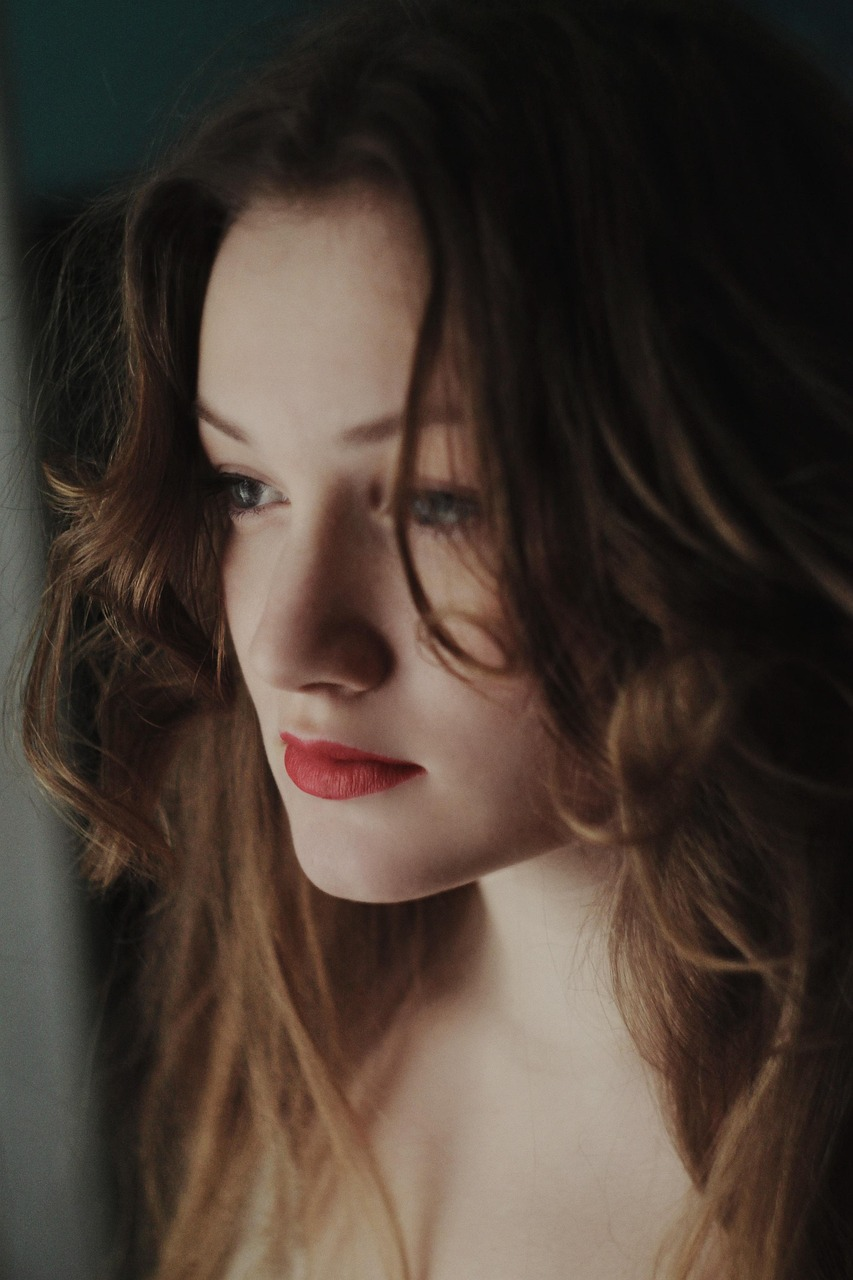

In [ ]:
import cv2
import dlib
import requests
import numpy as np
from google.colab.patches import cv2_imshow

# 1. 인공지능이 얼굴을 찾고 점을 찍을 때 쓸 '설계도(학습 모델)' 다운로드
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

# 2. 얼굴 탐지기와 랜드마크 예측기 초기화
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# 3. 인터넷에서 테스트용 얼굴 사진 한 장 실시간으로 가져오기
url = 'https://cdn.pixabay.com/photo/2016/11/29/06/08/woman-1867715_1280.jpg'
response = requests.get(url)
img_array = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# 4. 이미지에서 얼굴 영역 찾기 (Bounding Box)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = detector(gray)

print(f"이미지에서 찾은 얼굴 개수: {len(faces)}개")

# 5. 찾은 얼굴 위에 68개 특징점 계산해서 화면에 그리기
for face in faces:
    # 얼굴 테두리 빨간색 사각형 그리기
    cv2.rectangle(img, (face.left(), face.top()), (face.right(), face.bottom()), (0, 0, 255), 2)

    # 68개 점 위치 계산
    landmarks = predictor(gray, face)

    # 68개 점을 초록색 동그라미로 표시
    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        cv2.circle(img, (x, y), 3, (0, 255, 0), -1)

# 6. 코랩 화면에 최종 결과 사진 띄우기
cv2_imshow(img)

In [ ]:
import cv2
import dlib
import requests
import numpy as np
from google.colab.patches import cv2_imshow

# 1. 인공지능이 얼굴을 찾고 점을 찍을 때 쓸 '설계도(학습 모델)' 다운로드
# (이미 다운로드 되었다면 빠르게 패스됩니다)
!wget -qN http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 -f shape_predictor_68_face_landmarks.dat.bz2 2> /dev/null

# 2. 얼굴 탐지기(Detector)와 랜드마크 예측기(Predictor) 초기화
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# 3. 확실한 정면을 보고 있는 테스트용 얼굴 사진 주소로 변경
url = 'https://cdn.pixabay.com/photo/2016/11/21/14/51/woman-1845814_1280.jpg'
response = requests.get(url)
img_array = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# 4. 이미지에서 얼굴 영역 찾기 (Bounding Box)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = detector(gray)

print(f"이미지에서 찾은 얼굴 개수: {len(faces)}개")

# 5. 찾은 얼굴 위에 68개 특징점 계산해서 화면에 그리기
for face in faces:
    # 얼굴 테두리에 빨간색 사각형 그리기 (두께 2)
    cv2.rectangle(img, (face.left(), face.top()), (face.right(), face.bottom()), (0, 0, 255), 2)

    # 68개 점 위치 계산
    landmarks = predictor(gray, face)

    # 68개 점을 초록색 동그라미로 사진 위에 표시 (반지름 3)
    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        cv2.circle(img, (x, y), 3, (0, 255, 0), -1)

# 6. 코랩 화면에 최종 결과 사진 띄우기
cv2_imshow(img)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


👉 아래 [파일 선택] 버튼을 눌러서 컴퓨터에 있는 정면 얼굴 사진을 아무거나 올려줘! 👈


Saving 스크린샷 2025-05-18 155640.png to 스크린샷 2025-05-18 155640.png

[결과] 이미지에서 찾은 얼굴 개수: 1개


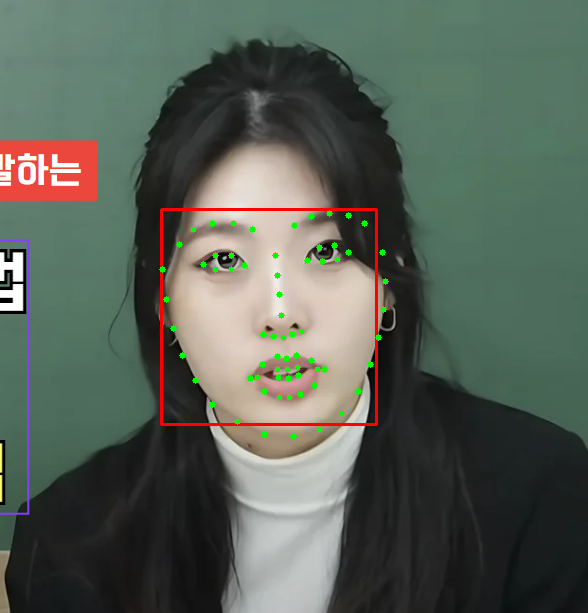

In [ ]:
import cv2
import dlib
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# 1. dlib 모델 설계도 다운로드 (안전장치 추가)
!wget -qN http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 -f shape_predictor_68_face_landmarks.dat.bz2 2> /dev/null

# 2. 얼굴 탐지기 및 랜드마크 예측기 초기화
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

print("👉 아래 [파일 선택] 버튼을 눌러서 컴퓨터에 있는 정면 얼굴 사진을 아무거나 올려줘! 👈")
uploaded = files.upload()

if uploaded:
    # 3. 업로드한 파일 이름을 알아내서 이미지로 읽기
    file_name = list(uploaded.keys())[0]
    img = cv2.decode = cv2.imread(file_name)

    if img is not None:
        # 4. 이미지에서 얼굴 영역 찾기
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = detector(gray)

        print(f"\n[결과] 이미지에서 찾은 얼굴 개수: {len(faces)}개")

        # 5. 찾은 얼굴 위에 68개 특징점 계산해서 그리기
        for face in faces:
            cv2.rectangle(img, (face.left(), face.top()), (face.right(), face.bottom()), (0, 0, 255), 2)

            landmarks = predictor(gray, face)
            for n in range(0, 68):
                x = landmarks.part(n).x
                y = landmarks.part(n).y
                cv2.circle(img, (x, y), 3, (0, 255, 0), -1)

        # 6. 결과 시각화
        cv2_imshow(img)
    else:
        print("이미지 파일을 읽어오는데 실패했습니다. 다른 사진으로 시도해보세요!")